# Topic 19: Generative Models — First Principles

**Goal:** Implement core generative modeling architectures (VAE, GAN, simplified Diffusion) from scratch in pure NumPy.

**Prerequisites:** Familiarity with neural networks, gradient descent, and autoencoders.

See [`theory.md`](theory.md) for mathematical derivations.

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2

SEED = 42
random.seed(SEED)
rng = np.random.default_rng(SEED)

plt.rcParams["figure.dpi"] = 90

## 1. Problem Setup — WHY

Generative models learn $p_{\text{data}}(x)$ to generate novel samples. We will use a synthetic 2D Gaussian mixture dataset to visualize latent spaces and generated samples easily.

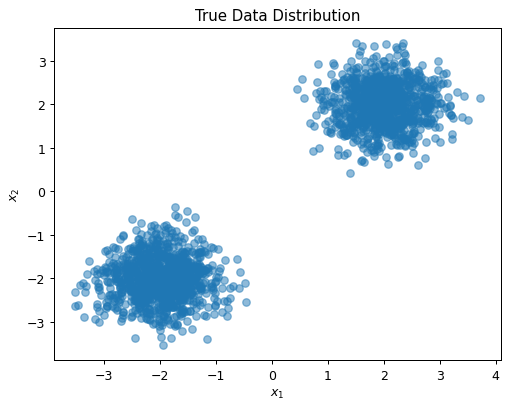

In [2]:
def generate_synthetic_data(n_samples=1000):
    # Two clusters (modes) to test mode collapse in GANs
    means = np.array([[2.0, 2.0], [-2.0, -2.0]])
    component = rng.integers(0, 2, size=n_samples)
    return rng.normal(loc=means[component], scale=0.5)

X_train = generate_synthetic_data(2000)
plt.scatter(X_train[:, 0], X_train[:, 1], alpha=0.5)
plt.title("True Data Distribution")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.show()

## 2. Mathematical Core — WHAT

- **VAE:** Maximize ELBO. $\mathcal{L} = \text{Reconstruction} - D_{\text{KL}}$.
- **GAN:** Minimax game between $G$ and $D$.
- **Diffusion (Forward):** $x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1 - \bar{\alpha}_t}\epsilon$.

## 3. Solution Method — HOW

We will construct pure NumPy layers (Linear, ReLU, Sigmoid) with explicit backward passes to build our VAE and GAN. For diffusion, we will simulate the forward marginals and visualize them.

In [3]:
class Linear:
    def __init__(self, in_dim, out_dim):
        self.W = rng.normal(0, 0.1, (in_dim, out_dim))
        self.b = np.zeros(out_dim)
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)
        self.x = None

    def forward(self, x):
        self.x = x
        return x @ self.W + self.b

    def backward(self, dout):
        self.dW = self.x.T @ dout
        self.db = np.sum(dout, axis=0)
        return dout @ self.W.T

    def update(self, lr):
        self.W -= lr * self.dW
        self.b -= lr * self.db

class ReLU:
    def forward(self, x):
        self.x = x
        return np.maximum(0, x)
    def backward(self, dout):
        return dout * (self.x > 0)

class Sigmoid:
    def forward(self, x):
        self.out = 1 / (1 + np.exp(-x))
        return self.out
    def backward(self, dout):
        return dout * self.out * (1 - self.out)

## 4. Implementation — BUILD
### Variational Autoencoder (VAE)

In [4]:
class VAE:
    def __init__(self, input_dim=2, hidden_dim=8, latent_dim=2):
        self.enc_l1 = Linear(input_dim, hidden_dim)
        self.enc_relu = ReLU()
        self.enc_mu = Linear(hidden_dim, latent_dim)
        self.enc_logvar = Linear(hidden_dim, latent_dim)
        
        self.dec_l1 = Linear(latent_dim, hidden_dim)
        self.dec_relu = ReLU()
        self.dec_out = Linear(hidden_dim, input_dim)
        
    def reparameterize(self, mu, logvar):
        std = np.exp(0.5 * logvar)
        eps = rng.normal(0, 1, size=std.shape)
        return mu + eps * std, eps, std
        
    def forward(self, x):
        h = self.enc_relu.forward(self.enc_l1.forward(x))
        mu = self.enc_mu.forward(h)
        logvar = self.enc_logvar.forward(h)
        
        z, eps, std = self.reparameterize(mu, logvar)
        
        h_dec = self.dec_relu.forward(self.dec_l1.forward(z))
        recon = self.dec_out.forward(h_dec)
        
        return recon, mu, logvar, z, eps, std
        
    def backward(self, x, recon, mu, logvar, z, eps, std):
        batch_size = x.shape[0]
        
        drecon = (recon - x) / batch_size
        dmu_kl = mu / batch_size
        dlogvar_kl = -0.5 * (1 - np.exp(logvar)) / batch_size
        
        dh_dec = self.dec_out.backward(drecon)
        dz = self.dec_l1.backward(self.dec_relu.backward(dh_dec))
        
        dmu = dz + dmu_kl
        dlogvar = dz * 0.5 * eps * std + dlogvar_kl
        
        dh = self.enc_mu.backward(dmu) + self.enc_logvar.backward(dlogvar)
        self.enc_l1.backward(self.enc_relu.backward(dh))
        
    def update(self, lr):
        for layer in [self.enc_l1, self.enc_mu, self.enc_logvar, self.dec_l1, self.dec_out]:
            layer.update(lr)

### Generative Adversarial Network (GAN)

In [5]:
class Generator:
    def __init__(self, latent_dim=2, hidden_dim=8, out_dim=2):
        self.l1 = Linear(latent_dim, hidden_dim)
        self.relu = ReLU()
        self.out = Linear(hidden_dim, out_dim)
    def forward(self, z):
        return self.out.forward(self.relu.forward(self.l1.forward(z)))
    def backward(self, dout):
        return self.l1.backward(self.relu.backward(self.out.backward(dout)))
    def update(self, lr):
        self.l1.update(lr); self.out.update(lr)

class Discriminator:
    def __init__(self, in_dim=2, hidden_dim=8):
        self.l1 = Linear(in_dim, hidden_dim)
        self.relu = ReLU()
        self.out = Linear(hidden_dim, 1)
        self.sig = Sigmoid()
    def forward(self, x):
        return self.sig.forward(self.out.forward(self.relu.forward(self.l1.forward(x))))
    def backward(self, dout):
        return self.l1.backward(self.relu.backward(self.out.backward(self.sig.backward(dout))))
    def update(self, lr):
        self.l1.update(lr); self.out.update(lr)

def bce_loss_and_grad(pred, target):
    epsilon = 1e-12
    pred = np.clip(pred, epsilon, 1 - epsilon)
    loss = -np.mean(target * np.log(pred) + (1 - target) * np.log(1 - pred))
    grad = (pred - target) / (pred * (1 - pred) * pred.shape[0])
    return loss, grad

## 5. Library Comparison
No mainstream library exposes a bare ELBO function, so the pinned unit-tested `ml_first_principles.generative_models` implementation plus analytic KL values serve as the reference here.

In [6]:
from ml_first_principles.generative_models import (
    VAE as VAERef,
    gan_discriminator_loss,
    gan_generator_loss,
    vae_elbo_loss,
)

def kl_divergence(mu, logvar):
    return -0.5 * np.sum(1 + logvar - mu**2 - np.exp(logvar))

# (a) Full ELBO check: run the package VAE on inputs in [0, 1] (its decoder ends in a
# sigmoid, so the reconstruction term is a binary cross-entropy) and reproduce
# vae_elbo_loss = BCE + KL, both summed over the batch, with eps=1e-12 inside the logs.
vae_ref = VAERef(input_dim=2, hidden_dim=16, latent_dim=2, random_state=SEED)
x01 = rng.uniform(0, 1, (64, 2))
recon_ref, mu_ref, logvar_ref = vae_ref.forward(x01)

eps_log = 1e-12
bce = -np.sum(x01 * np.log(recon_ref + eps_log) + (1 - x01) * np.log(1 - recon_ref + eps_log))
elbo_ours = bce + kl_divergence(mu_ref, logvar_ref)
elbo_ref = vae_elbo_loss(recon_ref, x01, mu_ref, logvar_ref)
assert np.isclose(elbo_ours, elbo_ref, rtol=1e-10), "ELBO mismatch vs package reference"

# (b) Analytic KL values: KL(N(0, I) || N(0, I)) = 0 exactly, and for logvar = 0
# the closed form collapses to 0.5 * sum(mu^2).
assert kl_divergence(np.zeros((1, 2)), np.zeros((1, 2))) == 0.0
mu_test = np.array([[0.5, -1.5]])
assert kl_divergence(mu_test, np.zeros((1, 2))) == 0.5 * np.sum(mu_test**2)

print(f"ELBO matches package reference: {elbo_ref:.4f}")

ELBO matches package reference: 162.5381


## 6. Experiments and Failures — VERIFY
### VAE Training and Evaluation

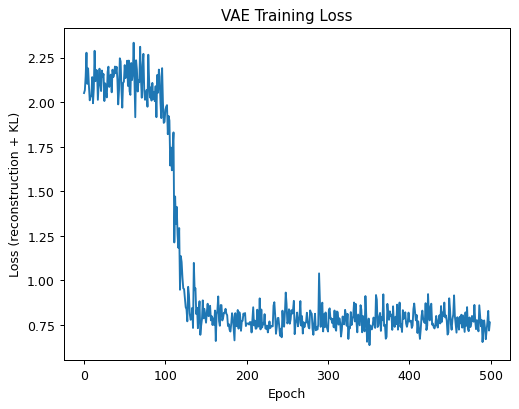

In [7]:
vae = VAE(input_dim=2, hidden_dim=16, latent_dim=2)
epochs = 500
batch_size = 64
lr = 0.05
losses = []

for epoch in range(epochs):
    idx = rng.integers(0, X_train.shape[0], size=batch_size)
    batch = X_train[idx]
    
    recon, mu, logvar, z, eps, std = vae.forward(batch)
    vae.backward(batch, recon, mu, logvar, z, eps, std)
    vae.update(lr)
    
    recon_loss = 0.5 * np.mean((recon - batch)**2)
    kl_loss = -0.5 * np.mean(1 + logvar - mu**2 - np.exp(logvar))
    losses.append(recon_loss + kl_loss)

plt.plot(losses)
plt.title("VAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (reconstruction + KL)")
plt.show()

Visualize VAE Latent Space:

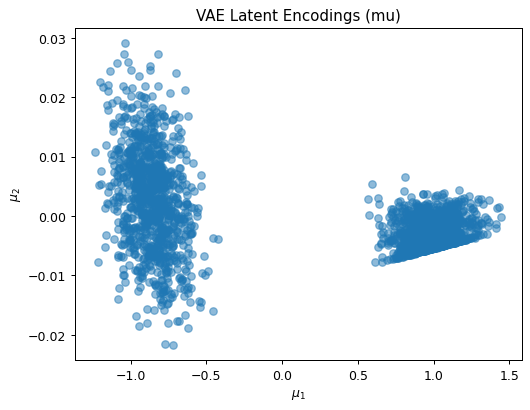

In [8]:
recon, mu, _, _, _, _ = vae.forward(X_train)
plt.scatter(mu[:, 0], mu[:, 1], alpha=0.5)
plt.title("VAE Latent Encodings (mu)")
plt.xlabel(r"$\mu_1$")
plt.ylabel(r"$\mu_2$")
plt.show()

### GAN Training and Mode Collapse

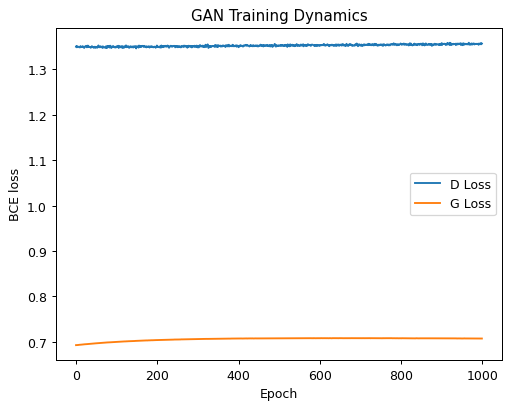

Final losses match package reference: D=1.3573, G=0.7074


In [9]:
G = Generator(latent_dim=2, hidden_dim=16, out_dim=2)
D = Discriminator(in_dim=2, hidden_dim=16)

epochs = 1000
batch_size = 64
lr = 0.01

d_losses = []
g_losses = []

for epoch in range(epochs):
    # Train D
    idx = rng.integers(0, X_train.shape[0], size=batch_size)
    real_data = X_train[idx]
    z = rng.normal(0, 1, (batch_size, 2))
    fake_data = G.forward(z)
    
    pred_real = D.forward(real_data)
    pred_fake = D.forward(fake_data)
    
    d_loss_real, d_grad_real = bce_loss_and_grad(pred_real, np.ones_like(pred_real))
    d_loss_fake, d_grad_fake = bce_loss_and_grad(pred_fake, np.zeros_like(pred_fake))
    
    D.backward(d_grad_real)
    D.update(lr)
    D.backward(d_grad_fake)
    D.update(lr)
    
    # Train G
    z = rng.normal(0, 1, (batch_size, 2))
    fake_data = G.forward(z)
    pred_fake = D.forward(fake_data)
    
    g_loss, g_grad = bce_loss_and_grad(pred_fake, np.ones_like(pred_fake))
    d_grad_fake = D.backward(g_grad)
    G.backward(d_grad_fake)
    G.update(lr)
    
    d_losses.append(d_loss_real + d_loss_fake)
    g_losses.append(g_loss)

plt.plot(d_losses, label="D Loss")
plt.plot(g_losses, label="G Loss")
plt.legend()
plt.title("GAN Training Dynamics")
plt.xlabel("Epoch")
plt.ylabel("BCE loss")
plt.show()

# Tie our BCE-based losses to the package reference on a fresh evaluation batch
idx = rng.integers(0, X_train.shape[0], size=batch_size)
pred_real = D.forward(X_train[idx])
pred_fake = D.forward(G.forward(rng.normal(0, 1, (batch_size, 2))))
d_loss_ours = (bce_loss_and_grad(pred_real, np.ones_like(pred_real))[0]
               + bce_loss_and_grad(pred_fake, np.zeros_like(pred_fake))[0])
g_loss_ours = bce_loss_and_grad(pred_fake, np.ones_like(pred_fake))[0]
assert np.isclose(d_loss_ours, gan_discriminator_loss(pred_real, pred_fake), atol=1e-9)
assert np.isclose(g_loss_ours, gan_generator_loss(pred_fake), atol=1e-9)
print(f"Final losses match package reference: D={d_loss_ours:.4f}, G={g_loss_ours:.4f}")

Visualizing **Mode Collapse** failure in GAN (often standard GAN only models one mode):

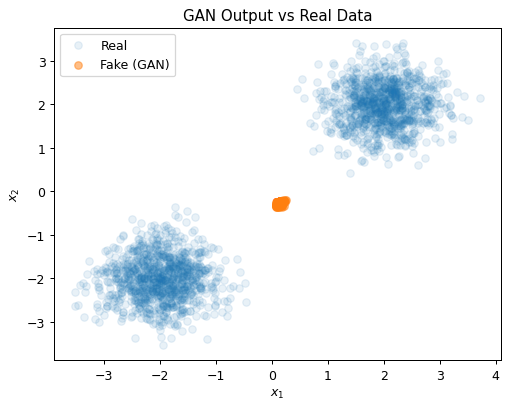

In [10]:
z_sample = rng.normal(0, 1, (1000, 2))
fake_samples = G.forward(z_sample)

plt.scatter(X_train[:, 0], X_train[:, 1], alpha=0.1, label="Real")
plt.scatter(fake_samples[:, 0], fake_samples[:, 1], alpha=0.5, label="Fake (GAN)")
plt.legend()
plt.title("GAN Output vs Real Data")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.show()

### Diffusion: Forward Noising and an Exact-Score Reverse ODE

This is **not** a full DDPM — no noise-prediction network is trained. We first visualize the forward (noising) process, then reverse it on our toy 2-component Gaussian mixture, where the score $\nabla_x \log p_t(x)$ is available in closed form.

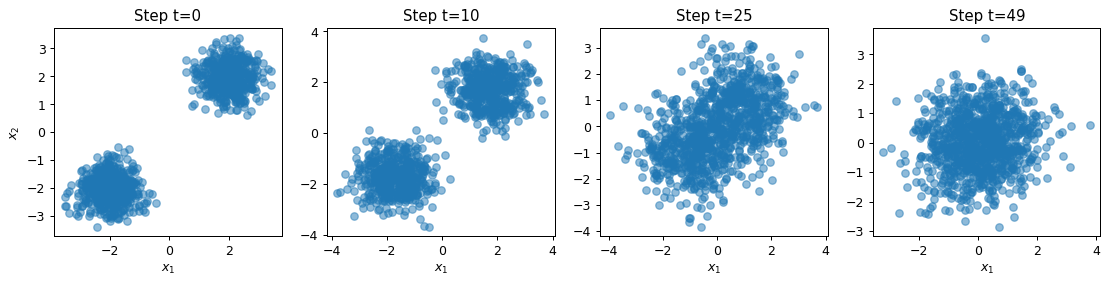

In [11]:
# Simple visualization of forward process
T = 50
beta = np.linspace(0.01, 0.2, T)
alpha = 1 - beta
alpha_bar = np.cumprod(alpha)

x_0 = X_train[:1000]

fig, axes = plt.subplots(1, 4, figsize=(15, 3))
steps = [0, 10, 25, 49]

for i, step in enumerate(steps):
    if step == 0:
        axes[i].scatter(x_0[:, 0], x_0[:, 1], alpha=0.5)
    else:
        noise = rng.normal(0, 1, x_0.shape)
        x_t = np.sqrt(alpha_bar[step]) * x_0 + np.sqrt(1 - alpha_bar[step]) * noise
        axes[i].scatter(x_t[:, 0], x_t[:, 1], alpha=0.5)
    axes[i].set_title(f"Step t={step}")
    axes[i].set_xlabel(r"$x_1$")
axes[0].set_ylabel(r"$x_2$")
plt.show()

### Reverse Process with the Exact Score

For $p_0 = \frac{1}{2}\sum_k \mathcal{N}(m_k, s_0^2 I)$ the forward marginal stays a Gaussian mixture,

$$p_t = \frac{1}{2}\sum_k \mathcal{N}\!\big(\sqrt{\bar{\alpha}_t}\, m_k,\ (\bar{\alpha}_t s_0^2 + 1 - \bar{\alpha}_t)\, I\big),$$

so the score is available in closed form:

$$\nabla_x \log p_t(x) = \sum_k r_k(x)\, \frac{\sqrt{\bar{\alpha}_t}\, m_k - x}{\bar{\alpha}_t s_0^2 + 1 - \bar{\alpha}_t}, \qquad r_k(x) \propto \mathcal{N}\!\big(x;\ \sqrt{\bar{\alpha}_t}\, m_k,\ (\bar{\alpha}_t s_0^2 + 1 - \bar{\alpha}_t)\, I\big).$$

We plug this exact score into deterministic DDIM-style Euler steps via $\hat{\epsilon}_t = -\sqrt{1-\bar{\alpha}_t}\,\nabla_x \log p_t(x)$ and integrate from seeded noise back to the data — this is what a trained DDPM approximates with a learned $\hat{\epsilon}_\theta$.

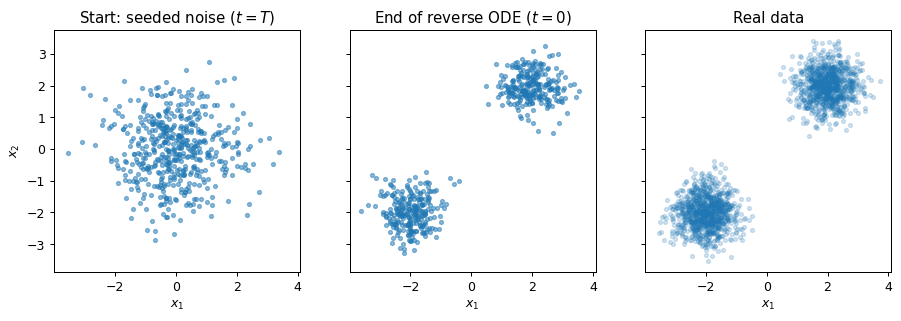

Fraction of samples within 1.5 of a mixture mean: 0.980


In [12]:
MIX_MEANS = np.array([[2.0, 2.0], [-2.0, -2.0]])
DATA_STD = 0.5  # per-component std used in generate_synthetic_data

def mixture_score(x, t):
    """Closed-form score of the diffused mixture marginal p_t (equal weights)."""
    ab = alpha_bar[t]
    means_t = np.sqrt(ab) * MIX_MEANS
    var_t = ab * DATA_STD**2 + (1 - ab)
    diff = x[:, None, :] - means_t[None, :, :]       # (n, K, 2)
    log_r = -0.5 * np.sum(diff**2, axis=-1) / var_t  # log responsibilities (up to const)
    log_r -= log_r.max(axis=1, keepdims=True)
    r = np.exp(log_r)
    r /= r.sum(axis=1, keepdims=True)
    return -np.sum(r[:, :, None] * diff, axis=1) / var_t

# Deterministic reverse integration (DDIM-style Euler steps on the probability flow)
x_rev = rng.normal(0, 1, (500, 2))  # p_T is approximately N(0, I)
x_start = x_rev.copy()
for t in range(T - 1, 0, -1):
    ab_t, ab_prev = alpha_bar[t], alpha_bar[t - 1]
    eps_hat = -np.sqrt(1 - ab_t) * mixture_score(x_rev, t)
    x0_hat = (x_rev - np.sqrt(1 - ab_t) * eps_hat) / np.sqrt(ab_t)
    x_rev = np.sqrt(ab_prev) * x0_hat + np.sqrt(1 - ab_prev) * eps_hat

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True, sharey=True)
axes[0].scatter(x_start[:, 0], x_start[:, 1], alpha=0.5, s=10)
axes[0].set_title("Start: seeded noise ($t=T$)")
axes[1].scatter(x_rev[:, 0], x_rev[:, 1], alpha=0.5, s=10)
axes[1].set_title("End of reverse ODE ($t=0$)")
axes[2].scatter(X_train[:, 0], X_train[:, 1], alpha=0.2, s=10)
axes[2].set_title("Real data")
for ax in axes:
    ax.set_xlabel(r"$x_1$")
axes[0].set_ylabel(r"$x_2$")
plt.show()

# The vast majority of recovered samples should land near a mixture mean
# (component std is 0.5, so radius 1.5 = 3 std; ~99% of true samples fall inside)
nearest = np.min(np.linalg.norm(x_rev[:, None, :] - MIX_MEANS[None], axis=-1), axis=1)
frac_close = np.mean(nearest < 1.5)
print(f"Fraction of samples within 1.5 of a mixture mean: {frac_close:.3f}")
assert frac_close >= 0.95, "Reverse ODE failed to recover the mixture"

## 7. Connections
- See how VAE directly maximizes the evidence lower bound (Topic 17).
- See how Discriminator builds on binary classification (Topic 13).